In [3]:
from pathlib import Path
import sys
import pandas as pd

import torch
from torch.utils.data import DataLoader

# --- Helper to find project root automatically ---
def find_project_root(start: Path) -> Path:
    """
    Walk upwards from `start` until we find a directory that has 'src' and 'data'.
    """
    cur = start.resolve()
    for p in [cur] + list(cur.parents):
        if (p / "src").is_dir() and (p / "data").is_dir():
            return p
    raise RuntimeError(f"Could not find project root starting from {start}")

# 1) Detect project root
cwd = Path.cwd()
project_root = find_project_root(cwd)
print("CWD         :", cwd)
print("PROJECT_ROOT:", project_root)

# 2) Add project_root to sys.path so `import src.*` works
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))
print("project_root in sys.path:", str(project_root) in sys.path)

# 3) Imports from your src/ modules
from src.models import DomainCNN
from src.datasets import DomainClassificationDataset, pad_collate_fn

# 4) Paths for A4 data + checkpoint
META_DIR = project_root / "data" / "processed" / "metadata"
CSV_PATH_A4 = META_DIR / "domain_classification_sentences_A4_emuru_realistic.csv"
CHECKPOINT_A4 = project_root / "checkpoints" / "domain_cnn_best_A4_emuru_realistic.pt"

print("\nCSV_PATH_A4  :", CSV_PATH_A4)
print("CHECKPOINT_A4:", CHECKPOINT_A4)

# 5) Quick CSV sanity
df_A4 = pd.read_csv(CSV_PATH_A4)
print("\nA4 CSV shape:", df_A4.shape)
print("hf_split values:", df_A4["hf_split"].unique())
print("source counts:\n", df_A4["source"].value_counts())
print("domain_label counts:\n", df_A4["domain_label"].value_counts())

# 6) Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("\nUsing device:", device)

# 7) Build A4 test dataset & loader (no aug, no norm – A4 is already 'baked')
test_ds_A4 = DomainClassificationDataset(
    csv_path=CSV_PATH_A4,
    project_root=project_root,
    split="test",
    augment_train=False,
    photo_aug_train=False,
    normalize_all=False,
)

test_loader_A4 = DataLoader(
    test_ds_A4,
    batch_size=64,
    shuffle=False,
    collate_fn=pad_collate_fn,
)

# 8) Load model + A4 checkpoint
model_A4 = DomainCNN().to(device)
print("\nModel:", model_A4.__class__.__name__)

if CHECKPOINT_A4.exists():
    state = torch.load(CHECKPOINT_A4, map_location=device)
    model_A4.load_state_dict(state)
    print("Loaded A4 checkpoint from:", CHECKPOINT_A4)
else:
    print("WARNING: A4 checkpoint not found, using randomly initialized model!")

model_A4.eval()


CWD         : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/notebooks
PROJECT_ROOT: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project
project_root in sys.path: True

CSV_PATH_A4  : /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/data/processed/metadata/domain_classification_sentences_A4_emuru_realistic.csv
CHECKPOINT_A4: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_project/checkpoints/domain_cnn_best_A4_emuru_realistic.pt

A4 CSV shape: (19602, 7)
hf_split values: ['test' 'train' 'validation']
source counts:
 source
iam      9801
emuru    9801
Name: count, dtype: int64
domain_label counts:
 domain_label
0    9801
1    9801
Name: count, dtype: int64

Using device: cpu
DomainClassificationDataset: 5506 samples (csv='domain_classification_sentences_A4_emuru_realistic.csv', split='test', augment_train=False, photo_aug_train=False, normalize_all=False)

Model: DomainCNN
Loaded A4 checkpoint from: /home/hpc/iwi5/iwi5384h/projects/handwriting_forge_proje

DomainCNN(
  (conv_block): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
  )
  (fc): Linear(in_features=128, out_features=2, bias=True)
)

In [4]:
import numpy as np

all_true = []
all_pred = []
all_prob_fake = []  # probability for class 1 (Emuru/fake)
all_sources = []
all_idxs = []
all_texts = []

model_A4.eval()

with torch.no_grad():
    for batch in test_loader_A4:
        images = batch["images"].to(device)   # (B, 1, 64, W_max)
        labels = batch["labels"].to(device)   # (B,)

        logits = model_A4(images)             # (B, 2)
        probs = torch.softmax(logits, dim=1)  # (B, 2)
        pred = logits.argmax(dim=1)           # (B,)

        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob_fake.extend(probs[:, 1].cpu().numpy().tolist())  # class 1

        all_sources.extend(batch["sources"])
        all_idxs.extend(batch["idxs"])
        all_texts.extend(batch["texts"])

# Build DataFrame with results
test_results_A4 = pd.DataFrame({
    "true_label": all_true,
    "pred_label": all_pred,
    "prob_fake": all_prob_fake,
    "source": all_sources,
    "idx": all_idxs,
    "text": all_texts,
})

print("test_results_A4 shape:", test_results_A4.shape)
display(test_results_A4.head())

# Quick accuracy sanity check
acc_A4 = (test_results_A4["true_label"] == test_results_A4["pred_label"]).mean()
print(f"\nA4_emuru_realistic test accuracy (recomputed): {acc_A4*100:.2f}%")


test_results_A4 shape: (5506, 6)


,true_label,pred_label,prob_fake,source,idx,text
0,0,0,0.321954,iam,7957,commerce may be kept going - though if ever
1,0,0,0.411350,iam,9341,"' Be silent , woman , and listen , ' Band Appa..."
2,1,1,0.729149,emuru,8143,"Easterly winds , on the other hand ,"
3,1,1,0.780793,emuru,10368,"just dusty-grey but muddy , slimy even ."
4,0,0,0.359556,iam,8651,needed taxation in order to supplement



A4_emuru_realistic test accuracy (recomputed): 83.51%


In [5]:
num_classes = 2
cm_A4 = np.zeros((num_classes, num_classes), dtype=int)

for t, p in zip(test_results_A4["true_label"], test_results_A4["pred_label"]):
    cm_A4[t, p] += 1

print("Confusion matrix (A4; rows = true, cols = pred):")
print("       pred=0    pred=1")
print(f"true=0   {cm_A4[0,0]:6d}   {cm_A4[0,1]:6d}")
print(f"true=1   {cm_A4[1,0]:6d}   {cm_A4[1,1]:6d}")

acc0_A4 = cm_A4[0,0] / cm_A4[0].sum() if cm_A4[0].sum() > 0 else 0.0
acc1_A4 = cm_A4[1,1] / cm_A4[1].sum() if cm_A4[1].sum() > 0 else 0.0

print("\nPer-class accuracy (A4):")
print(f"  Class 0 (IAM / genuine): {acc0_A4*100:.2f}%")
print(f"  Class 1 (Emuru_A4 / fake): {acc1_A4*100:.2f}%")


Confusion matrix (A4; rows = true, cols = pred):
       pred=0    pred=1
true=0     1904      849
true=1       59     2694

Per-class accuracy (A4):
  Class 0 (IAM / genuine): 69.16%
  Class 1 (Emuru_A4 / fake): 97.86%


Number of misclassified test samples (A4): 908
Misclassified merged shape (A4): (908, 8)

Rows to show: 8
idx: 7709 | source: iam
text: 'are used on Passover , to depict the " time of our freedom " .'
true_label    : 0 (0=IAM/genuine, 1=Emuru_A4/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.5906
filepath: data/raw/iam/iam_07709.png


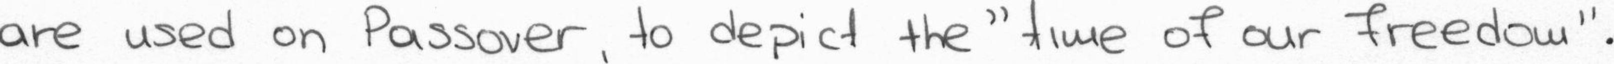

idx: 9937 | source: iam
text: 'unreadable as a rock . " Let \'s get over to the'
true_label    : 0 (0=IAM/genuine, 1=Emuru_A4/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.9185
filepath: data/raw/iam/iam_09937.png


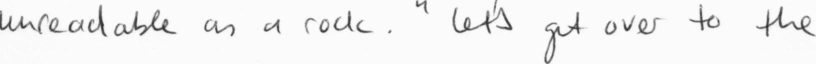

idx: 9626 | source: iam
text: 'on the estate was a major error :'
true_label    : 0 (0=IAM/genuine, 1=Emuru_A4/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.7413
filepath: data/raw/iam/iam_09626.png


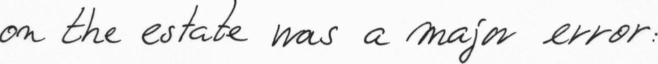

idx: 9787 | source: iam
text: '" Oh , the Press , " said Seaweed . " Down here on business , Mr.'
true_label    : 0 (0=IAM/genuine, 1=Emuru_A4/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.7776
filepath: data/raw/iam/iam_09787.png


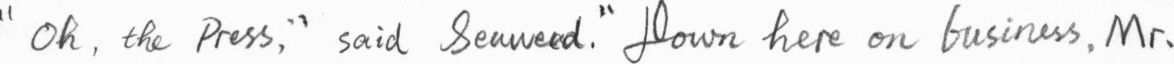

idx: 9197 | source: iam
text: 'trees and bushes , that stood well out over the lake .'
true_label    : 0 (0=IAM/genuine, 1=Emuru_A4/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.9477
filepath: data/raw/iam/iam_09197.png


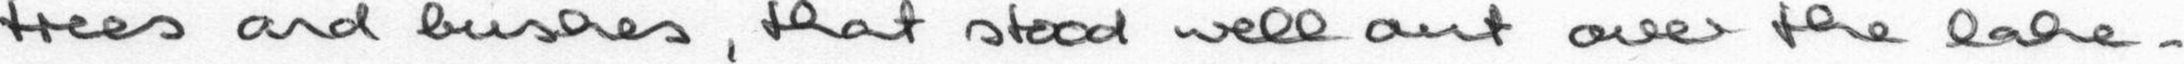

idx: 7840 | source: iam
text: 'the way to face life . To see all the latent'
true_label    : 0 (0=IAM/genuine, 1=Emuru_A4/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.8429
filepath: data/raw/iam/iam_07840.png


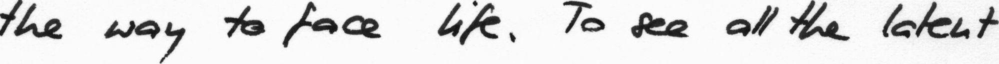

idx: 8122 | source: iam
text: 'be accidental . Yet there will always be some'
true_label    : 0 (0=IAM/genuine, 1=Emuru_A4/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.7741
filepath: data/raw/iam/iam_08122.png


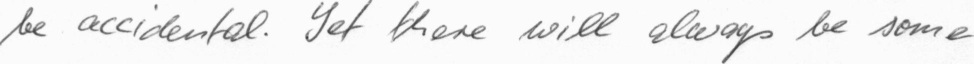

idx: 9183 | source: iam
text: 'any rate they remained with us , perhaps'
true_label    : 0 (0=IAM/genuine, 1=Emuru_A4/fake)
pred_label    : 1
prob_fake (p(class=1)) = 0.5193
filepath: data/raw/iam/iam_09183.png


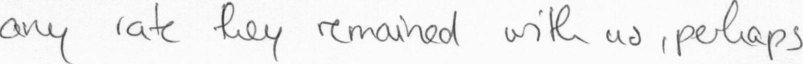

In [7]:
from IPython.display import display
from PIL import Image
from src.datasets import load_line_image  # reuse resize

# 1) Misclassified rows
mis_A4 = test_results_A4[test_results_A4["true_label"] != test_results_A4["pred_label"]].copy()
print("Number of misclassified test samples (A4):", len(mis_A4))

# 2) Restrict A4 df to test split only
df_A4_test = df_A4[df_A4["hf_split"] == "test"].copy()

# Merge to get filepath (from A4 CSV)
mis_merged_A4 = mis_A4.merge(
    df_A4_test[["idx", "source", "filepath", "domain_label"]],
    on=["idx", "source"],
    how="left",
    suffixes=("", "_orig")
)

print("Misclassified merged shape (A4):", mis_merged_A4.shape)

if len(mis_merged_A4) == 0:
    print("\nNo misclassifications for A4 🎉")
    print("Showing borderline examples instead.")
    # borderline = closest to prob_fake = 0.5
    test_results_A4["dist_to_0_5"] = (test_results_A4["prob_fake"] - 0.5).abs()
    rows_to_show = test_results_A4.sort_values("dist_to_0_5").head(8).merge(
        df_A4_test[["idx", "source", "filepath", "domain_label"]],
        on=["idx", "source"],
        how="left",
        suffixes=("", "_orig"),
    )
else:
    rows_to_show = mis_merged_A4.head(8)

print("\nRows to show:", len(rows_to_show))

for i, row in rows_to_show.iterrows():
    print("=" * 80)
    print(f"idx: {row['idx']} | source: {row['source']}")
    print(f"text: {repr(row['text'])}")
    print(f"true_label    : {row['true_label']} (0=IAM/genuine, 1=Emuru_A4/fake)")
    print(f"pred_label    : {row['pred_label']}")
    print(f"prob_fake (p(class=1)) = {row['prob_fake']:.4f}")
    print(f"filepath: {row['filepath']}")

    img_path = project_root / row["filepath"]

    try:
        # A4 training did not use normalization, so just load raw-resized
        t = load_line_image(
            img_path,
            normalize=False,
        )
        arr = (t.squeeze(0).numpy() * 255).astype("uint8")
        pil_img = Image.fromarray(arr, mode="L")
        display(pil_img)
    except Exception as e:
        print("  Could not load/display image:", e)


Using N = 1500 points for t-SNE
Feature matrix shape: (1500, 128)
t-SNE embedding shape (A4): (1500, 2)


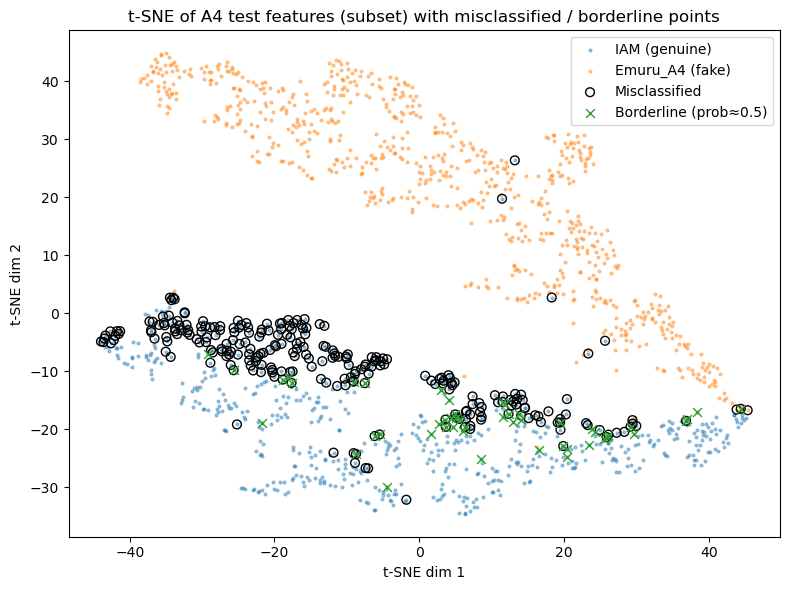

In [8]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# Limit how many test samples we use for t-SNE
MAX_POINTS = 1500  # adjust if needed

all_feats = []
all_true = []
all_pred = []
all_prob_fake = []
all_sources = []
all_idxs = []
all_texts = []

model_A4.eval()
with torch.no_grad():
    for batch in test_loader_A4:
        images = batch["images"].to(device)   # (B, 1, 64, W_max)
        labels = batch["labels"]
        sources = batch["sources"]
        idxs = batch["idxs"]
        texts = batch["texts"]

        logits = model_A4(images)             # (B, 2)
        probs = torch.softmax(logits, dim=1)
        pred = logits.argmax(dim=1)

        feats = model_A4.conv_block(images)   # (B, C, H', W')
        feats = feats.mean(dim=[2, 3])        # (B, C)

        all_feats.append(feats.cpu().numpy())
        all_true.extend(labels.cpu().numpy().tolist())
        all_pred.extend(pred.cpu().numpy().tolist())
        all_prob_fake.extend(probs[:, 1].cpu().numpy().tolist())
        all_sources.extend(sources)
        all_idxs.extend(idxs)
        all_texts.extend(texts)

        if len(all_true) >= MAX_POINTS:
            break

# Stack and truncate to exactly MAX_POINTS
X = np.concatenate(all_feats, axis=0)
N = min(len(all_true), MAX_POINTS)
X = X[:N]
y_true = np.array(all_true[:N])
y_pred = np.array(all_pred[:N])
prob_fake = np.array(all_prob_fake[:N])
sources_sub = all_sources[:N]
idxs_sub = all_idxs[:N]
texts_sub = all_texts[:N]

print("Using N =", N, "points for t-SNE")
print("Feature matrix shape:", X.shape)

# 2) t-SNE on the subset
tsne = TSNE(
    n_components=2,
    init="random",
    learning_rate="auto",
    random_state=42,
    perplexity=30,
)
X_emb = tsne.fit_transform(X)
print("t-SNE embedding shape (A4):", X_emb.shape)

# 3) Build DataFrame for convenience
vis_df = pd.DataFrame({
    "true_label": y_true,
    "pred_label": y_pred,
    "prob_fake": prob_fake,
    "source": sources_sub,
    "idx": idxs_sub,
    "text": texts_sub,
})

# Misclassified & borderline masks
mis_mask = (vis_df["true_label"] != vis_df["pred_label"]).to_numpy()

vis_df["dist_to_0_5"] = (vis_df["prob_fake"] - 0.5).abs()
borderline_idx = vis_df["dist_to_0_5"].nsmallest(50).index
borderline_mask = np.zeros(len(vis_df), dtype=bool)
borderline_mask[borderline_idx.to_numpy()] = True

iam_mask = (vis_df["true_label"].to_numpy() == 0)
emu_mask = (vis_df["true_label"].to_numpy() == 1)

# 4) Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    X_emb[iam_mask, 0],
    X_emb[iam_mask, 1],
    s=4,
    alpha=0.4,
    label="IAM (genuine)",
)
plt.scatter(
    X_emb[emu_mask, 0],
    X_emb[emu_mask, 1],
    s=4,
    alpha=0.4,
    label="Emuru_A4 (fake)",
)

if mis_mask.any():
    plt.scatter(
        X_emb[mis_mask, 0],
        X_emb[mis_mask, 1],
        s=40,
        edgecolors="k",
        facecolors="none",
        linewidths=1.0,
        label="Misclassified",
    )

plt.scatter(
    X_emb[borderline_mask, 0],
    X_emb[borderline_mask, 1],
    s=40,
    marker="x",
    linewidths=1.0,
    label="Borderline (prob≈0.5)",
)

plt.title("t-SNE of A4 test features (subset) with misclassified / borderline points")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.tight_layout()
plt.show()
